# **1. Perkenalan Dataset**


Pada proyek ini, saya menggunakan dataset **Credit Risk** (Risiko Kredit) untuk membangun model klasifikasi.

*   **Nama Dataset:** Credit Risk Dataset
*   **Sumber/Tautan:** https://www.kaggle.com/datasets/laotse/credit-risk-dataset
*   **Ringkasan:** Dataset ini berisi informasi historis nasabah peminjam kredit, termasuk fitur-fitur seperti pendapatan, usia, lama bekerja, jumlah pinjaman, dan status gagal bayar (default). Tujuan penggunaan dataset ini adalah untuk melatih model Machine Learning agar dapat memprediksi apakah seorang nasabah baru berisiko gagal bayar atau tidak.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Library untuk Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings('ignore')

print("Library berhasil diimpor!")

Library berhasil diimpor!


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [3]:
# Memuat dataset
file_path = 'credit_risk_dataset.csv'
df = pd.read_csv(file_path)

# Menampilkan 5 baris pertama dan informasi dataset
display(df.head())
print("-" * 50)
df.info()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
me

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

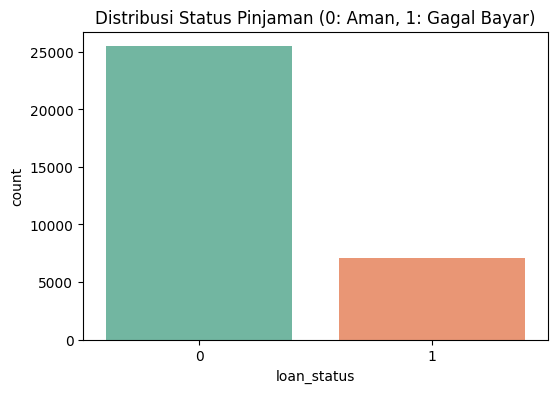

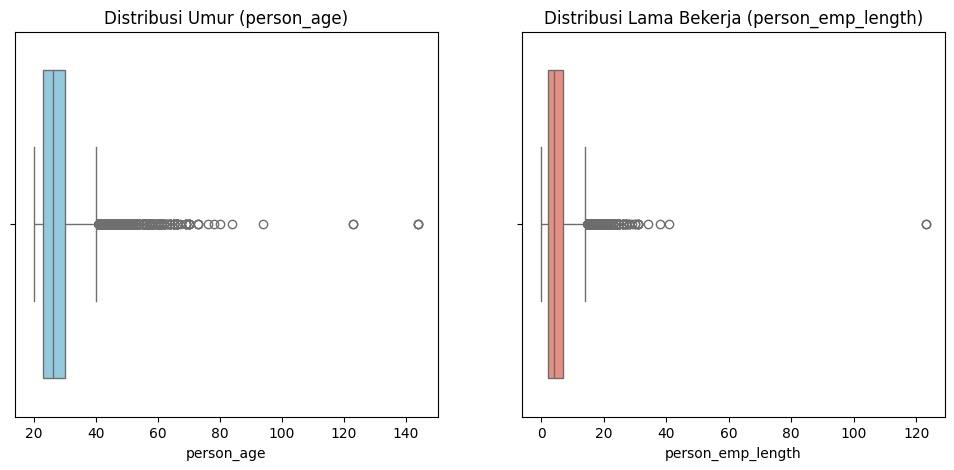

Missing Values per Kolom:
person_emp_length     895
loan_int_rate        3116
dtype: int64


In [4]:
# 1. Mengecek distribusi target class (loan_status)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='loan_status', palette='Set2')
plt.title('Distribusi Status Pinjaman (0: Aman, 1: Gagal Bayar)')
plt.show()

# 2. Mengecek anomali (Outlier) pada umur dan lama bekerja
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x='person_age', ax=axes[0], color='skyblue')
axes[0].set_title('Distribusi Umur (person_age)')

sns.boxplot(data=df, x='person_emp_length', ax=axes[1], color='salmon')
axes[1].set_title('Distribusi Lama Bekerja (person_emp_length)')
plt.show()

# 3. Mengecek jumlah missing values
print("Missing Values per Kolom:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [5]:
# --- 1. Menghapus Outlier Ekstrem ---
# Menghapus umur di atas 100 tahun dan lama bekerja di atas 60 tahun
df_clean = df[(df['person_age'] <= 100) & (df['person_age'].notnull())]
# Kita gunakan fillna sementara untuk kondisi agar baris dengan NaN tidak ikut terhapus
df_clean = df_clean[(df_clean['person_emp_length'].fillna(0) <= 60)]

print(f"Jumlah baris setelah hapus outlier ekstrem: {df_clean.shape[0]}")

# --- 2. Pemisahan Fitur dan Target ---
X = df_clean.drop('loan_status', axis=1)
y = df_clean['loan_status']

# Split data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- 3. Membangun Pipeline Preprocessing ---
# Memisahkan kolom numerik dan kategorikal
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

# Pipeline untuk data numerik (Imputasi Median + Standarisasi)
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline untuk data kategorikal (Imputasi Modus + One Hot Encoding)
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Menggabungkan pipeline dengan ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

# --- 4. Mengaplikasikan Preprocessing ---
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Bentuk X_train setelah preprocessing:", X_train_processed.shape)
print("Bentuk X_test setelah preprocessing:", X_test_processed.shape)

# Menyimpan data bersih untuk dipakai di tahapan Modelling nanti
pd.DataFrame(X_train_processed).to_csv('X_train_clean.csv', index=False)
y_train.to_csv('y_train_clean.csv', index=False)

Jumlah baris setelah hapus outlier ekstrem: 32574
Bentuk X_train setelah preprocessing: (26059, 26)
Bentuk X_test setelah preprocessing: (6515, 26)
